## **Implementação de Redes Perceptron: Aprendendo OR**

A função **OR** recebe dois valores $x_1$ e $x_2$, pertencentes ao conjunto $\{0, 1\}$, e mapeia o resultado de acordo com a tabela verdade:

| $x_1$ | $x_2$ | Saída |
|:---:|:---:|:---:|
| $1$ | $1$ | $1$ |
| $1$ | $0$ | $1$ |
| $0$ | $1$ | $1$ |
| $0$ | $0$ | $0$ |

É um problema linearmente separável, portanto pode ser resolvido por uma rede Perceptron¹.

> ¹ Pelo **Teorema de Rosenblatt** (1958), o Perceptron converge em um número finito de passos para qualquer problema linearmente separável.

**Importando a biblioteca ``torch`` e ``torch.nn`` usada para Redes Neurais**

In [ ]:
import torch
import torch.nn as nn

**Criando o dataset usando um tensor**

In [ ]:
X = torch.tensor([[0,0],[0,1],[1,0],[1,1]], dtype=torch.float32)
T = torch.tensor([[0],[1],[1],[1]],         dtype=torch.float32)

**Criando o modelo seguindo o seguinte padrão:**

In [ ]:
model = nn.Sequential(
    nn.Linear(2, 1),
    nn.Sigmoid()
)

Dado que é uma rede perceptron, definimos:

$$
\text{model} = \text{Sequential}\bigl(
    \underbrace{\text{Linear}(2,1)}_{\mathbf{w} \in \mathbb{R}^{1\times2},\; {b} \in \mathbb{R}},\;
    \sigma
\bigr)
$$

A única camada existente computa:

$$
a = \mathbf{w}^{\top}\mathbf{x} + b
$$

e aplica a função de ativação:

$$
z = \sigma(a)
$$

**Loss e Otimizador**

Aqui vamos utilizar como função de perda a *Binary Cross-Entropy (BCE)* e como otimizador o *Stochastic Gradient Descent (SGD)*:

In [ ]:
criterion = nn.BCELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.5)

**Treino**

In [ ]:
losses = []

for epoch in range(10000):
    y = model(X)
    loss = criterion(y, T)
    losses.append(loss.item())
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 1000 == 0:
            print(f"Época {epoch:5d}  |  E = {loss:.6f}")

Época     0  |  E = 0.655664
Época  1000  |  E = 0.018798
Época  2000  |  E = 0.009291
Época  3000  |  E = 0.006153
Época  4000  |  E = 0.004595
Época  5000  |  E = 0.003666
Época  6000  |  E = 0.003048
Época  7000  |  E = 0.002608
Época  8000  |  E = 0.002279
Época  9000  |  E = 0.002024


**Curva de Aprendizado**

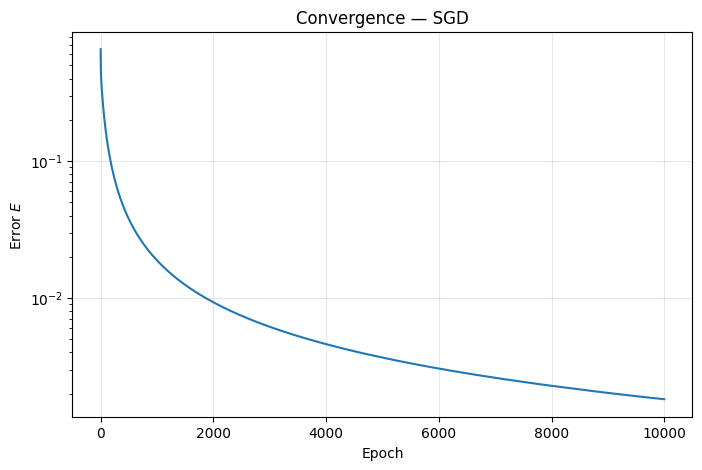

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel(r"Error $E$")
plt.title("Convergence — SGD")
plt.grid(True, alpha=0.3)
plt.yscale("log")
plt.show()

**Parâmetros do Modelo**

In [ ]:
for name, param in model.named_parameters():
    print(f"{name}: {param.data}")

0.weight: tensor([[11.9345, 11.9345]])
0.bias: tensor([-5.5077])


**Inferência**

In [ ]:
with torch.no_grad():
    print(model(X).round())

tensor([[0.],
        [1.],
        [1.],
        [1.]])
